<a href="https://colab.research.google.com/github/remziicnnn/cifar10-cnn-image-classification/blob/main/proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# CIFAR-10 veri kümesini yükle
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Veriyi normalize et
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Etiketleri one-hot encoding yap
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


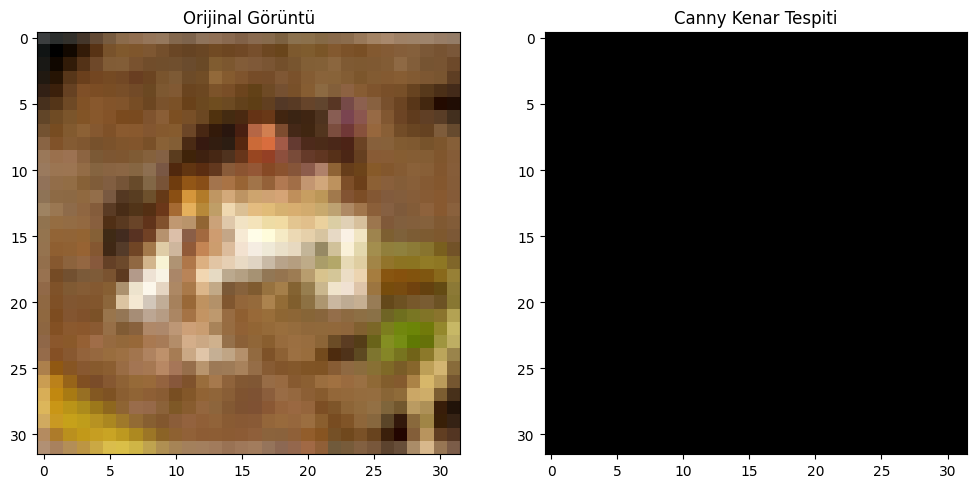

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Bir görüntüyü seç
sample_image = X_train[0]

# Gri tonlamaya dönüştür
gray_image = cv2.cvtColor(sample_image, cv2.COLOR_RGB2GRAY)

# Gri tonlamalı görüntüyü uint8 formatına dönüştür
gray_image_uint8 = np.uint8(gray_image)

# Canny kenar tespiti uygula
edges = cv2.Canny(gray_image_uint8, 100, 200)

# Görüntüyü ve kenarları görselleştir
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(sample_image)
plt.title("Orijinal Görüntü")
plt.subplot(1, 2, 2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Kenar Tespiti")
plt.show()



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Modeli eğit
cnn_history = cnn_model.fit(X_train, y_train_cat, epochs=10, validation_data=(X_test, y_test_cat), batch_size=64)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 86ms/step - accuracy: 0.3173 - loss: 1.8424 - val_accuracy: 0.5344 - val_loss: 1.3282
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 88ms/step - accuracy: 0.5168 - loss: 1.3519 - val_accuracy: 0.5897 - val_loss: 1.1861
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.5674 - loss: 1.2293 - val_accuracy: 0.6350 - val_loss: 1.0520
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 83ms/step - accuracy: 0.6031 - loss: 1.1384 - val_accuracy: 0.6585 - val_loss: 0.9938
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 84ms/step - accuracy: 0.6225 - loss: 1.0786 - val_accuracy: 0.6608 - val_loss: 0.9767
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 86ms/step - accuracy: 0.6330 - loss: 1.0404 - val_accuracy: 0.6741 - val_loss: 0.9321
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 85ms/step - accuracy: 0.6470 - loss: 0.9983 - val_accuracy: 0.6807 - val_loss: 0.9255
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 86ms/step - accuracy: 0.6632 - loss: 0.9676 - 